In [1]:
import numpy as np
from scipy.integrate import RK45
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors 
from collections import deque

# Constants

In [2]:
g = 9.81 # acceleration due to gravity on Earth (ms^-1)

# Derivatives



In [3]:
def derivatives(t, state, mass, length):
    angle_1, angular_velocity_1, angle_2, angular_velocity_2 = state
    mass_1, mass_2 = mass
    length_1, length_2 = length

    delta = angle_1 - angle_2
    sin_delta = np.sin(delta)
    cos_delta = np.cos(delta)

    derivative_1 = (
        -mass_2 * length_1 * (angular_velocity_1 ** 2) * sin_delta * cos_delta +
        mass_2 * g * np.sin(angle_2) * cos_delta -
        mass_2 * length_2 * (angular_velocity_2 ** 2) * sin_delta -
        (mass_1 + mass_2) * g * np.sin(angle_1)
    )/((mass_1 + mass_2) * length_1 - mass_2 * length_1 * (cos_delta ** 2))

    derivative_2 = (
        (mass_1 + mass_2) * length_1 * (angular_velocity_1 ** 2) * sin_delta -
        (mass_1 + mass_2) * g * np.sin(angle_2) +
        (mass_1 + mass_2) * g * np.sin(angle_1) * cos_delta + 
        mass_2 * length_2 * (angular_velocity_2 ** 2) * sin_delta * cos_delta
    )/((mass_1 + mass_2) * length_2 - mass_2 * length_2 * (cos_delta ** 2))

    return np.array([angular_velocity_1, derivative_1, angular_velocity_2, derivative_2])

# Pendulum Physics

In [4]:
dt = 0.01 # step size

length = [2, 1]
mass = [2, 1]
initial_angle = [170, 170]

In [5]:
solver = RK45(
    fun=lambda t, state: derivatives(t, state, mass, length),
    t0=0,
    y0=[np.radians(initial_angle[0]), 0, np.radians(initial_angle[1]), 0],
    t_bound=np.inf,
    max_step=dt
)

# Simulation

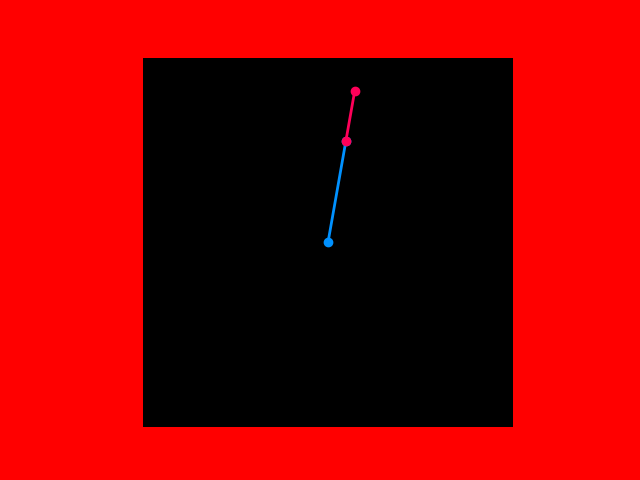

In [ ]:
%matplotlib widget

mfig, ax = plt.subplots()

# hide matplotlib widget ui
mfig.canvas.toolbar_visible = False
mfig.canvas.header_visible = False
mfig.canvas.footer_visible = False

PENDULUM_1_HEX = "#0091FF"
PENDULUM_2_HEX = "#ff0059"

# black background colour
ax.set_facecolor('black')
mfig.patch.set_facecolor('black')

# hide axes
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

total_length = np.sum(length) # lengths of pendulum 1 + pendulum 2

# set x and y axes to fit pendulum
ax.set_xlim(-(total_length * 1.2), total_length * 1.2)
ax.set_ylim(-(total_length * 1.2), total_length * 1.2)
ax.set_aspect("equal")

# pendulum 2 trace
TRACE_LENGTH = 100000
trace_x = deque(maxlen=TRACE_LENGTH)
trace_y = deque(maxlen=TRACE_LENGTH)
trace_collection = LineCollection([], lw=1, color=PENDULUM_2_HEX)
ax.add_collection(trace_collection)

# pendulum 1
initial_position_1 = length[0] * np.array([np.sin(solver.y[0]), -np.cos(solver.y[0])])
string_1, = ax.plot([0, initial_position_1[0]], [0, initial_position_1[1]], "o-", linewidth=2.0, color=PENDULUM_1_HEX)

# pendulum 2
initial_position_2 = initial_position_1 + (length[1] * np.array([np.sin(solver.y[2]), -np.cos(solver.y[2])])) 
string_2, = ax.plot([initial_position_1[0], initial_position_2[0]], [initial_position_1[1], initial_position_2[1]], "o-", linewidth=2.0, color=PENDULUM_2_HEX)


def update(i):
    # step solver forward by dt
    solver.step()
    state = solver.y

    # pendulum 1
    new_position_1 = length[0] * np.array([np.sin(state[0]), -np.cos(state[0])])
    string_1.set_data([0, new_position_1[0]], [0, new_position_1[1]])

    # pendulum 2
    new_position_2 = new_position_1 + (length[1] * np.array([np.sin(state[2]), -np.cos(state[2])])) 
    string_2.set_data([new_position_1[0], new_position_2[0]], [new_position_1[1], new_position_2[1]])
    
    # update trace to pendulum 2 new position
    trace_x.append(new_position_2[0])
    trace_y.append(new_position_2[1])

    tx = list(trace_x)
    ty = list(trace_y)
    n = len(tx)

    # fade trace over time
    if n > 1:
        points = np.array([tx, ty]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        red, green, blue = mcolors.to_rgb(PENDULUM_2_HEX)
        
        alphas = np.linspace(0, 0.8, len(segments))
        colors = [(red, green, blue, a) for a in alphas]
        
        trace_collection.set_colors(colors)
        trace_collection.set_segments(segments)
    
    return string_1, string_2, trace_collection

anim = animation.FuncAnimation(mfig, update, interval=dt*1000, cache_frame_data=False)

plt.show()